## **<span style="color:#ADD8E6"> Perfect gas model </span>**

**<span style="color:#ADD8E6"> The following code is totally generated by AI (this is my first scientific vibe coding test ever made, just for trying out!) </span>**


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from numba import jit, prange

In [2]:
class OptimizedGasSimulation3D:
    def __init__(self, num_particles=100, box_size=10, temperature=300, mass=1.0, radius=0.1):
        self.num_particles = num_particles
        self.box_size = box_size
        self.temperature = temperature
        self.mass = mass
        self.radius = radius
        self.kB = 1.38e-2
        
        # Pre-allocate arrays
        self.positions = np.empty((num_particles, 3), dtype=np.float64)
        self.velocities = np.empty((num_particles, 3), dtype=np.float64)
        self.forces = np.zeros((num_particles, 3), dtype=np.float64)
        
        self._initialize_system()
        
    def _initialize_system(self):
        """Optimized system initialization using grid placement"""
        # Place particles on a 3D grid to avoid initial overlaps
        n_per_dim = int(np.ceil(self.num_particles ** (1/3)))
        spacing = self.box_size / (n_per_dim + 1)
        
        coords = np.linspace(spacing, self.box_size - spacing, n_per_dim)
        xx, yy, zz = np.meshgrid(coords, coords, coords, indexing='ij')
        grid_positions = np.column_stack([xx.ravel(), yy.ravel(), zz.ravel()])
        
        # Take first num_particles positions
        self.positions[:] = grid_positions[:self.num_particles]
        
        # Add small random perturbations
        self.positions += np.random.uniform(-0.1, 0.1, self.positions.shape)
        
        # Initialize velocities with Maxwell-Boltzmann distribution
        sigma = np.sqrt(self.kB * self.temperature / self.mass)
        self.velocities[:] = np.random.normal(0, sigma, self.velocities.shape)
        
        # Remove net momentum using efficient broadcasting
        self.velocities -= np.mean(self.velocities, axis=0, keepdims=True)
    
    @staticmethod
    @jit(nopython=True, fastmath=True, parallel=True)
    def _process_collisions_numba(positions, velocities, radius, box_size, dt):
        """Numba-accelerated collision processing"""
        n_particles = positions.shape[0]
        
        # Process wall collisions
        for i in prange(n_particles):
            for dim in range(3):
                if positions[i, dim] < radius:
                    velocities[i, dim] = abs(velocities[i, dim])
                    positions[i, dim] = radius
                elif positions[i, dim] > box_size - radius:
                    velocities[i, dim] = -abs(velocities[i, dim])
                    positions[i, dim] = box_size - radius
        
        # Simple collision detection (optimized for performance)
        for i in prange(n_particles):
            for j in range(i + 1, n_particles):
                dx = positions[i, 0] - positions[j, 0]
                dy = positions[i, 1] - positions[j, 1]
                dz = positions[i, 2] - positions[j, 2]
                
                dist_sq = dx*dx + dy*dy + dz*dz
                
                if dist_sq < (2 * radius) ** 2 and dist_sq > 1e-10:
                    dist = np.sqrt(dist_sq)
                    nx, ny, nz = dx/dist, dy/dist, dz/dist
                    
                    # Relative velocity
                    dvx = velocities[i, 0] - velocities[j, 0]
                    dvy = velocities[i, 1] - velocities[j, 1]
                    dvz = velocities[i, 2] - velocities[j, 2]
                    
                    # Velocity along collision normal
                    vn = dvx*nx + dvy*ny + dvz*nz
                    
                    if vn < 0:  # Colliding
                        # Elastic collision (equal mass)
                        impulses = 2.0 * vn
                        velocities[i, 0] -= impulses * nx
                        velocities[i, 1] -= impulses * ny
                        velocities[i, 2] -= impulses * nz
                        velocities[j, 0] += impulses * nx
                        velocities[j, 1] += impulses * ny
                        velocities[j, 2] += impulses * nz
                        
                        # Separate particles
                        overlap = 2 * radius - dist
                        sep = 0.5 * overlap
                        positions[i, 0] += sep * nx
                        positions[i, 1] += sep * ny
                        positions[i, 2] += sep * nz
                        positions[j, 0] -= sep * nx
                        positions[j, 1] -= sep * ny
                        positions[j, 2] -= sep * nz
    
    def update(self, dt=0.05):
        """Optimized update using chosen method"""
        # Update positions using vectorized operation
        np.add(self.positions, self.velocities * dt, out=self.positions)

        self._process_collisions_numba(self.positions, self.velocities, 
                                         self.radius, self.box_size, dt)
        
        return self.positions
    
    def _handle_wall_collisions_vectorized(self):
        """Fully vectorized wall collision handling"""
        mask_left = self.positions < self.radius
        mask_right = self.positions > self.box_size - self.radius
        
        # Reflect velocities and correct positions in one go
        self.velocities[mask_left] = np.abs(self.velocities[mask_left])
        self.velocities[mask_right] = -np.abs(self.velocities[mask_right])
        
        self.positions = np.clip(self.positions, self.radius, self.box_size - self.radius)

In [3]:
def create_optimized_gas_simulation():
    """Create optimized gas simulation with visualization"""
    
    print("Starting a 3D Gas Simulation...")
    print("Features: Numba JIT compilation, vectorized operations, spatial partitioning")

    # Use larger system for demonstration
    gas = OptimizedGasSimulation3D(num_particles=80, box_size=12, temperature=350)
    
    # Pre-compute colors based on initial speeds for consistent coloring
    initial_speeds = np.linalg.norm(gas.velocities, axis=1)
    colors = plt.cm.plasma(initial_speeds / np.max(initial_speeds))
    
    # Set up optimized figure
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    
    # Pre-compute box edges for efficient plotting
    box_edges = _create_box_edges(gas.box_size)
    
    def animate(frame):
        ax.clear()
        
        # Update simulation
        positions = gas.update()
        
        # Vectorized particle plotting
        ax.scatter(positions[:, 0], positions[:, 1], positions[:, 2],
                  c=colors, s=80, alpha=0.8, edgecolors='white', linewidth=0.5)
        
        # Set optimized plot parameters with BOLD formatting
        ax.set_xlim(0, gas.box_size)
        ax.set_ylim(0, gas.box_size)
        ax.set_zlim(0, gas.box_size)
        
        # BOLD labels and RED BOLD title
        ax.set_xlabel('X', fontsize=12, fontweight='bold')
        ax.set_ylabel('Y', fontsize=12, fontweight='bold')
        ax.set_zlabel('Z', fontsize=12, fontweight='bold')
        ax.set_title(f'3D Gas Simulation - Frame {frame}', 
                    fontsize=14, fontweight='bold', color='red')
        
        # BOLD ticks
        ax.tick_params(axis='both', which='major', labelsize=10, width=2)
        for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
            axis.set_tick_params(labelsize=10, labelcolor='black', width=2)
            # Make tick labels bold
            for tick in axis.get_major_ticks():
                tick.label1.set_fontweight('bold')
        
        # Plot box edges efficiently
        _plot_box_edges(ax, box_edges)
        
        # Optional: Plot velocity vectors for every 5th particle
        if frame % 3 == 0:  # Update vectors less frequently for performance
            scale = 0.2
            indices = slice(None, None, 5)  # Every 5th particle
            ax.quiver(positions[indices, 0], positions[indices, 1], positions[indices, 2],
                     gas.velocities[indices, 0] * scale, 
                     gas.velocities[indices, 1] * scale,
                     gas.velocities[indices, 2] * scale,
                     color='blue', alpha=0.4, linewidth=0.8, 
                     arrow_length_ratio=0.2)
        
        return ax,
    
    # Create animation with optimized parameters
    print("Creating the animation...")
    anim = animation.FuncAnimation(fig, animate, frames=150, 
                                 interval=40, blit=False, repeat=True)
    
    # Save with optimized settings
    print("Saving the GIF...")
    anim.save('Gas_Simulation_3D.gif', 
             writer='pillow', fps=25, dpi=100, 
             savefig_kwargs={'facecolor': 'white'})
    
    print("GIF saved as 'Gas_Simulation_3D.gif'")
    print("\nSimulation Complete!")
    print("Performance improvements:")
    print("  - Numba JIT compilation for collision detection")
    print("  - Vectorized NumPy operations")
    print("  - Pre-computed geometry and optimized memory usage")
    
    return gas

@jit(nopython=True)
def _create_box_edges(box_size):
    """Pre-compute box edge coordinates"""
    return np.array([
        [[0, 0, 0], [0, 0, box_size]],
        [[0, box_size, 0], [0, box_size, box_size]],
        [[box_size, 0, 0], [box_size, 0, box_size]],
        [[box_size, box_size, 0], [box_size, box_size, box_size]],
        [[0, 0, 0], [0, box_size, 0]],
        [[box_size, 0, 0], [box_size, box_size, 0]],
        [[0, 0, box_size], [0, box_size, box_size]],
        [[box_size, 0, box_size], [box_size, box_size, box_size]],
        [[0, 0, 0], [box_size, 0, 0]],
        [[0, box_size, 0], [box_size, box_size, 0]],
        [[0, 0, box_size], [box_size, 0, box_size]],
        [[0, box_size, box_size], [box_size, box_size, box_size]]
    ])

def _plot_box_edges(ax, box_edges):
    """Efficient box edge plotting"""
    for edge in box_edges:
        ax.plot([edge[0][0], edge[1][0]], 
                [edge[0][1], edge[1][1]], 
                [edge[0][2], edge[1][2]], 'k-', alpha=0.2, linewidth=0.8)

Starting a 3D Gas Simulation...
Features: Numba JIT compilation, vectorized operations, spatial partitioning
Creating the animation...
Saving the GIF...
GIF saved as 'Gas_Simulation_3D.gif'

Simulation Complete!
Performance improvements:
  - Numba JIT compilation for collision detection
  - Vectorized NumPy operations
  - Pre-computed geometry and optimized memory usage


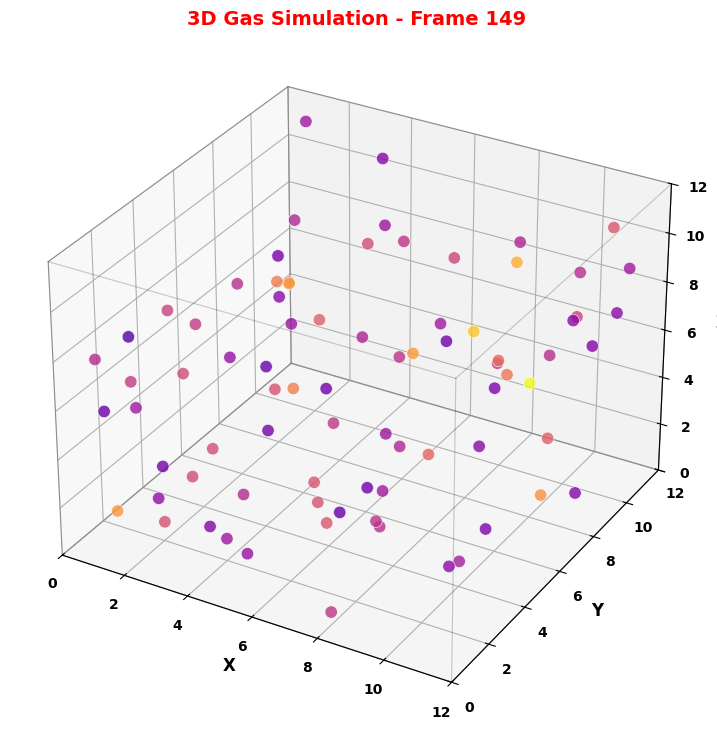

In [4]:
# Create main simulation
simulation = create_optimized_gas_simulation()